# Análise de Crédito

## Definição dos Atributos

Identificacao: Um identificador único para cada cliente, numérico e sequencial (de 1 a 1000).

Idade: A idade do cliente em anos, variando entre 18 e 70 anos. Este campo contém aproximadamente 5% de valores nulos para simular dados ausentes.

Renda_Anual: A renda anual do cliente em reais, variando entre RS 80.000,00 e RS 500.000,00, com duas casas decimais. Valores extremos (outliers) foram introduzidos para simular rendas anormalmente altas em aproximadamente 2% dos registros. Esse campo também inclui aproximadamente 5% de valores nulos.

Valor_Emprestimo: O valor solicitado do empréstimo em reais, variando entre RS 200.000,00 e RS 800.000,00, com duas casas decimais. Outliers foram introduzidos, onde alguns valores foram reduzidos drasticamente para simular valores de empréstimos anormalmente baixos.

Duracao_Emprestimo: A duração do empréstimo em meses, variando entre 12 e 60 meses. Esse campo representa a quantidade de meses que o cliente tem para quitar o empréstimo.

Inadimplencias_Anteriores: Número de inadimplências anteriores registradas pelo cliente, variando de 0 a 4. Esse campo representa o histórico de inadimplências, indicando o número de vezes que o cliente não conseguiu cumprir compromissos financeiros no passado.

Pontuacao_Credito: A pontuação de crédito do cliente, variando entre 1 e 6. Uma pontuação mais alta geralmente indica menor risco de inadimplência, enquanto pontuações mais baixas indicam maior risco. Este campo também contém aproximadamente 5% de valores nulos.


## Pipeline

O pipeline em ciência de dados é uma sequência de etapas estruturadas para coletar, processar, e analisar dados com o objetivo de obter insights e modelos preditivos. Esse fluxo de trabalho organiza e padroniza o processo, aumentando a eficiência e facilitando a manutenção e a escalabilidade dos projetos de ciência de dados.

Etapa 1: Importar Bibliotecas

Etapa 2: Obter o Datasource

Etapa 3: Exibir os Dados, Metadados e Estatísticas

Etapa 4: Extract, Transform, Load (ETL)

Etapa 5: Exploratory Data Analysis (EDA)

Etapa 6: Identificação dos Outliers

Etapa 7: Definição das Regras

Etapa 8: Balanceamento dos Dados

Etapa 9: Normalização dos Dados

Etapa 10: Separação dos Dados para Treinamento/Teste e Validação

Etapa 11: Treinamento dos Modelos

Etapa 12: Competição de modelos

## Etapa 1: Importar Bibliotecas

In [ ]:
# Importar bibliotecas
try:
  import gdown
except ImportError:
  !pip install gdown
  import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Etapa 2: Obter o Datasource

In [ ]:
# Atribuir ID do arquivo no Google Drive
file_id = '19BNDVEbhRZzJJpol2LU7NT_eIMIdbFPC'
dataset_url = f'https://drive.google.com/uc?id={file_id}'

# Definir nome do arquivo
output_path = 'credito.csv'

# Baixar o arquivo usando gdown
gdown.download(dataset_url, output_path, quiet=False)

# Carregar o arquivo CSV em um DataFrame, especificando o separador como ponto-e-vírgula
dataset = pd.read_csv(output_path, sep=';')

Downloading...
From: https://drive.google.com/uc?id=19BNDVEbhRZzJJpol2LU7NT_eIMIdbFPC
To: /content/credito.csv
100%|██████████| 34.1k/34.1k [00:00<00:00, 28.0MB/s]


## Etapa 3: Exibir os Dados, Metadados e Estatísticas

In [ ]:
# Explorar os metadados do dataset
print("Exploração dos Dados e Metadados do Dataset\n")
print(dataset.head().to_string())
# Exibir o DataFrame


Exploração dos Dados e Metadados do Dataset

   ID  Idade  Renda_Anual  Valor_Emprestimo  Duracao_Emprestimo  Pontuacao_Credito  Inadimplencias_Anteriores
0   1   56.0    305368.07         548285.00                  24                5.0                          3
1   2   69.0    468097.54         253260.44                  30                1.0                          1
2   3    NaN    179168.94         776999.44                  60                NaN                          1
3   4   32.0    399181.27         580976.03                  17                1.0                          2
4   5   60.0    303131.62         652902.69                  59                3.0                          2


In [ ]:
# 2. Obter informações gerais do dataset
print("\n2. Informações Gerais do Dataset:")
print(dataset.info())


2. Informações Gerais do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1000 non-null   int64  
 1   Idade                      950 non-null    float64
 2   Renda_Anual                950 non-null    float64
 3   Valor_Emprestimo           1000 non-null   float64
 4   Duracao_Emprestimo         1000 non-null   int64  
 5   Pontuacao_Credito          950 non-null    float64
 6   Inadimplencias_Anteriores  1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB
None


In [ ]:
# 3. Exibir o número de linhas e colunas
print("\n3. Dimensões do Dataset (Linhas, Colunas):")
print(dataset.shape)



3. Dimensões do Dataset (Linhas, Colunas):
(1000, 7)


In [ ]:
# 4. Exibir o nome das colunas
print("\n4. Nomes das Colunas:")
print(dataset.columns.tolist())



4. Nomes das Colunas:
['ID', 'Idade', 'Renda_Anual', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Pontuacao_Credito', 'Inadimplencias_Anteriores']


In [ ]:
print("\n5. Dados Ausentes por Coluna:")
print(dataset.isnull().sum())


5. Dados Ausentes por Coluna:
ID                            0
Idade                        50
Renda_Anual                  50
Valor_Emprestimo              0
Duracao_Emprestimo            0
Pontuacao_Credito            50
Inadimplencias_Anteriores     0
dtype: int64


In [ ]:
# 6. Exibir tipos de dados de cada coluna
print("\n6. Tipos de Dados das Colunas:")
print(dataset.dtypes)



6. Tipos de Dados das Colunas:
ID                             int64
Idade                        float64
Renda_Anual                  float64
Valor_Emprestimo             float64
Duracao_Emprestimo             int64
Pontuacao_Credito            float64
Inadimplencias_Anteriores      int64
dtype: object


In [ ]:
# 7. Exibir estatísticas descritivas para colunas numéricas
print("\n7. Estatísticas Descritivas das Colunas Numéricas:")
print(dataset.describe().to_string())



7. Estatísticas Descritivas das Colunas Numéricas:
                ID       Idade   Renda_Anual  Valor_Emprestimo  Duracao_Emprestimo  Pontuacao_Credito  Inadimplencias_Anteriores
count  1000.000000  950.000000  9.500000e+02       1000.000000         1000.000000         950.000000                1000.000000
mean    500.500000   44.491579  3.051111e+05     488273.298240           36.438000           3.562105                   2.047000
std     288.819436   15.355274  1.445802e+05     180903.165518           14.329043           1.709034                   1.398122
min       1.000000   18.000000  8.009976e+04      46405.570000           12.000000           1.000000                   0.000000
25%     250.750000   32.000000  1.964853e+05     332473.007500           24.000000           2.000000                   1.000000
50%     500.500000   45.000000  3.048457e+05     491412.345000           36.500000           4.000000                   2.000000
75%     750.250000   57.000000  4.008450e+05 

## Etapa 4: Extract, Transform, Load (ETL)

In [ ]:
# Criar uma cópia do dataset
dataset_copy = dataset.copy()

# Preencher valores nulos de 'Idade' com a moda
if 'Idade' in dataset_copy.columns and dataset_copy['Idade'].isnull().any():
    dataset_copy['Idade'] = dataset_copy['Idade'].fillna(dataset_copy['Idade'].mode()[0])

# Preencher valores nulos de 'Renda_Anual' com a média
if 'Renda_Anual' in dataset_copy.columns and dataset_copy['Renda_Anual'].isnull().any():
    dataset_copy['Renda_Anual'] = dataset_copy['Renda_Anual'].fillna(dataset_copy['Renda_Anual'].mean())

# Preencher valores nulos de 'Pontuacao_Credito' com o valor máximo
if 'Pontuacao_Credito' in dataset_copy.columns and dataset_copy['Pontuacao_Credito'].isnull().any():
    dataset_copy['Pontuacao_Credito'] = dataset_copy['Pontuacao_Credito'].fillna(dataset_copy['Pontuacao_Credito'].max())

# Exibir os dados após a substituição
print("Dados após o preenchimento de valores nulos:")
display(dataset_copy.head())

# Exibir o dataset atualizado para confirmar as transformações
print("\nInformações gerais do dataset após as transformações:")
display(dataset_copy.info())
print("\nDados ausentes por coluna após as transformações:")
display(dataset_copy.isnull().sum())

Dados após o preenchimento de valores nulos:


,ID,Idade,Renda_Anual,Valor_Emprestimo,Duracao_Emprestimo,Pontuacao_Credito,Inadimplencias_Anteriores
0,1,56.0,305368.07,548285.00,24,5.0,3
1,2,69.0,468097.54,253260.44,30,1.0,1
2,3,52.0,179168.94,776999.44,60,6.0,1
3,4,32.0,399181.27,580976.03,17,1.0,2
4,5,60.0,303131.62,652902.69,59,3.0,2



Informações gerais do dataset após as transformações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1000 non-null   int64  
 1   Idade                      1000 non-null   float64
 2   Renda_Anual                1000 non-null   float64
 3   Valor_Emprestimo           1000 non-null   float64
 4   Duracao_Emprestimo         1000 non-null   int64  
 5   Pontuacao_Credito          1000 non-null   float64
 6   Inadimplencias_Anteriores  1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


None


Dados ausentes por coluna após as transformações:


,0
ID,0
Idade,0
Renda_Anual,0
Valor_Emprestimo,0
Duracao_Emprestimo,0
Pontuacao_Credito,0
Inadimplencias_Anteriores,0


## Etapa 5: Exploratory Data Analysis (EDA)


Tipos de Dados das Colunas:
ID                             int64
Idade                        float64
Renda_Anual                  float64
Valor_Emprestimo             float64
Duracao_Emprestimo             int64
Pontuacao_Credito            float64
Inadimplencias_Anteriores      int64
dtype: object


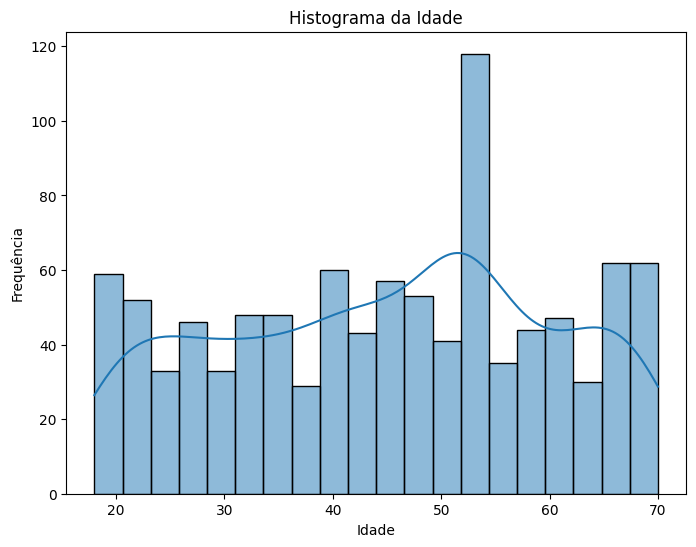

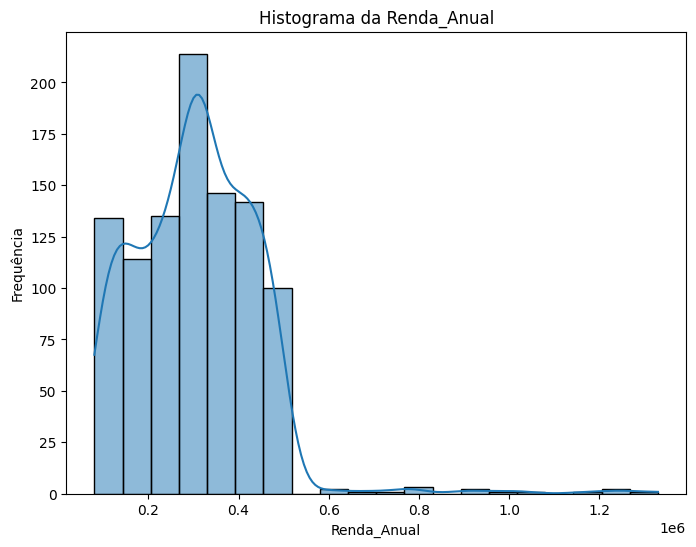

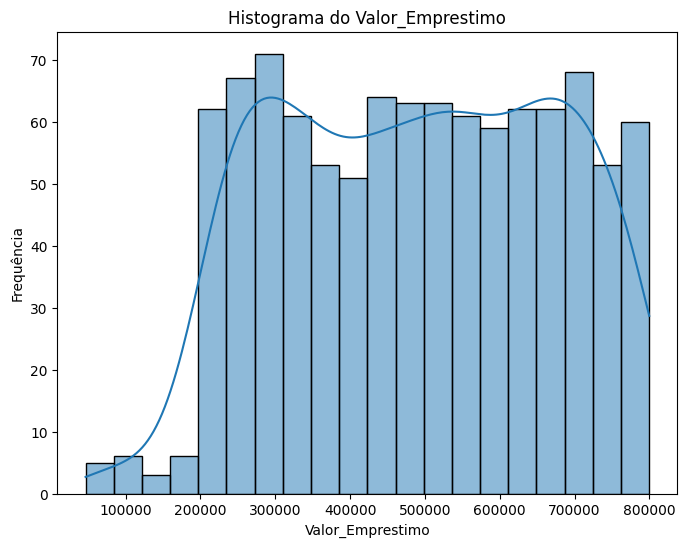

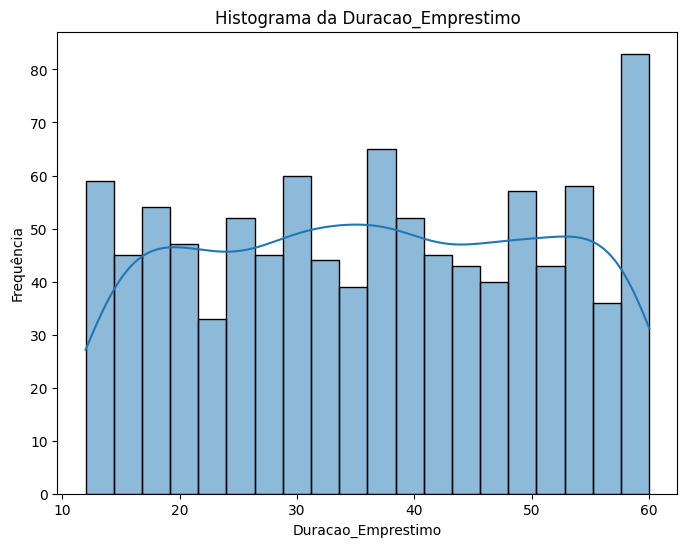

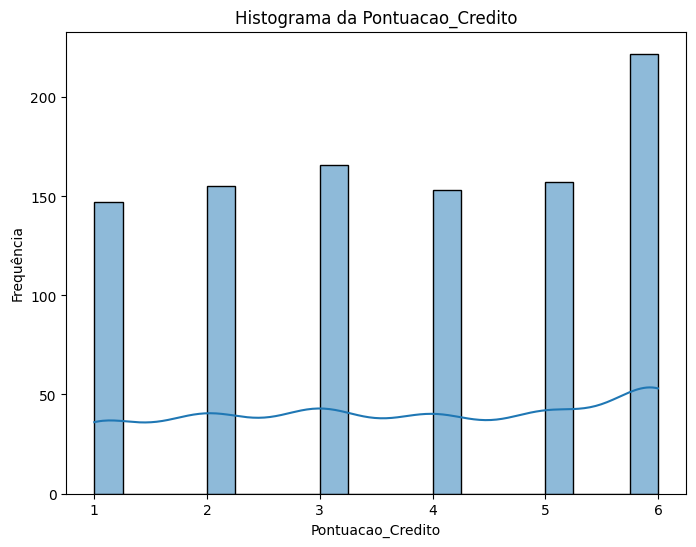

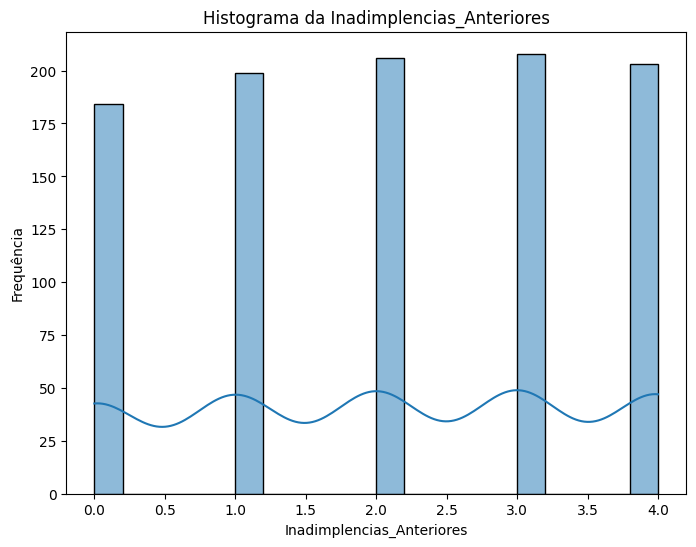

In [ ]:
# Exibir Metadados
print("\nTipos de Dados das Colunas:")
print(dataset_copy.dtypes)

# Plotar

# Histograma da Idade
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Idade'], bins=20, kde=True)
plt.title('Histograma da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Histograma da Renda_Anual
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Renda_Anual'], bins=20, kde=True)
plt.title('Histograma da Renda_Anual')
plt.xlabel('Renda_Anual')
plt.ylabel('Frequência')
plt.show()

# Histograma do Valor_Emprestimo
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Valor_Emprestimo'], bins=20, kde=True)
plt.title('Histograma do Valor_Emprestimo')
plt.xlabel('Valor_Emprestimo')
plt.ylabel('Frequência')
plt.show()

# Histograma da Duracao_Emprestimo
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Duracao_Emprestimo'], bins=20, kde=True)
plt.title('Histograma da Duracao_Emprestimo')
plt.xlabel('Duracao_Emprestimo')
plt.ylabel('Frequência')
plt.show()

# Histograma da Pontuacao_Credito
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Pontuacao_Credito'], bins=20, kde=True)
plt.title('Histograma da Pontuacao_Credito')
plt.xlabel('Pontuacao_Credito')
plt.ylabel('Frequência')
plt.show()

# Histograma da Inadimplencias_Anteriores
plt.figure(figsize=(8, 6))
sns.histplot(dataset_copy['Inadimplencias_Anteriores'], bins=20, kde=True)
plt.title('Histograma da Inadimplencias_Anteriores')
plt.xlabel('Inadimplencias_Anteriores')
plt.ylabel('Frequência')
plt.show()

## Etapa 6: Identificação dos Outliers

### Calcular Contaminação

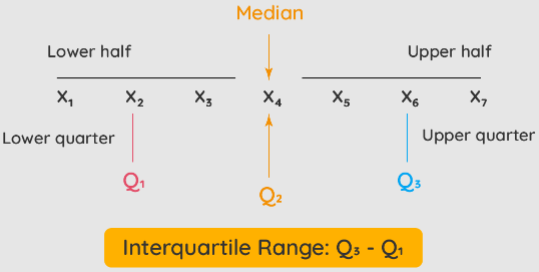

Para calcular o percentual de contaminação de outliers em um dataset, se pode usar o método InterQuartile Range (IQR) que serve para identificar os valores atípicos em cada coluna numérica. O IQR define outliers como valores que estão:

Abaixo de Q1 - 1.5 x IQR

ou

Acima de Q3 + 1.5 x IQR

In [ ]:
# Definir o limite
limite = 1.5 # Definido como 1.5 para o método IQR padrão

# Selecionar apenas colunas numéricas (excluindo 'ID' se não for relevante para outliers)
numeric_cols = dataset_copy.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

# Inicializar contador de outliers
outlier_counts = 0
total_values = numeric_cols.size

# Detectar outliers usando o método IQR para cada coluna numérica
print("Análise de Outliers por Coluna (Método IQR):")
for col in numeric_cols.columns:
    Q1 = numeric_cols[col].quantile(0.25)
    Q3 = numeric_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - limite * IQR
    upper_bound = Q3 + limite * IQR

    # Contar outliers
    col_outliers = numeric_cols[(numeric_cols[col] < lower_bound) | (numeric_cols[col] > upper_bound)][col].count()
    outlier_counts += col_outliers
    print(f"Coluna '{col}' - Outliers: {col_outliers} ({(col_outliers / len(dataset_copy) * 100):.2f}%) de registros com outliers nesta coluna)")

# Calcular o percentual de contaminação de outliers no dataset (considerando todos os valores numéricos)
outlier_percentage = (outlier_counts / total_values) * 100

print(f"\nPercentual total de contaminação de outliers no dataset (todos os valores numéricos): {outlier_percentage:.2f}%")
print(f"Valor de contaminação de outliers no dataset (para IsolationForest): {outlier_percentage/100:.4f}")

Análise de Outliers por Coluna (Método IQR):
Coluna 'Idade' - Outliers: 0 (0.00%) de registros com outliers nesta coluna)
Coluna 'Renda_Anual' - Outliers: 12 (1.20%) de registros com outliers nesta coluna)
Coluna 'Valor_Emprestimo' - Outliers: 0 (0.00%) de registros com outliers nesta coluna)
Coluna 'Duracao_Emprestimo' - Outliers: 0 (0.00%) de registros com outliers nesta coluna)
Coluna 'Pontuacao_Credito' - Outliers: 0 (0.00%) de registros com outliers nesta coluna)
Coluna 'Inadimplencias_Anteriores' - Outliers: 0 (0.00%) de registros com outliers nesta coluna)

Percentual total de contaminação de outliers no dataset (todos os valores numéricos): 0.20%
Valor de contaminação de outliers no dataset (para IsolationForest): 0.0020


### Interpretação do Boxplot

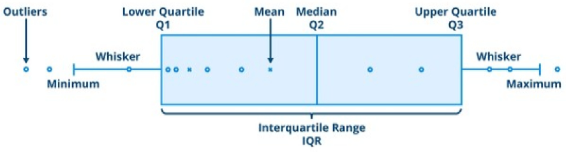

Boxplot da variável "Renda_Anual":

Mediana (linha laranja no meio da caixa): representa a mediana da renda anual, ficando um pouco abaixo de RS 400.000,00, o que indica que 50% das rendas estão abaixo desse valor e 50% estão acima.

Quartis (Q1 e Q3): a parte inferior da caixa representa o primeiro quartil (Q1), que é o valor abaixo do qual estão 25% dos dados e a parte superior da caixa representa o terceiro quartil (Q3), que é o valor abaixo do qual estão 75% dos dados.

Intervalo Interquartil (IQR): é a altura da caixa representa, que representa a diferença entre Q3 e Q1. Esse intervalo cobre os 50% centrais dos dados.

Limites (Bigodes): são as linhas verticais que se estendem até os valores que estão dentro de 1.5 x IQR de Q1 e Q3, sendo os limites para valores considerados "normais", pois os valores fora desses limites são considerados outliers.

Outliers (círculos acima da caixa): serve para indicar que existem valores de renda anual como outliers, sendo rendas que estão bem acima da maioria dos dados, sendo assim, considerados valores extremos. Esses pontos representam indivíduos (observações) com rendas anuais muito acima do restante do conjunto de dados.

O Boxplot informa que a maioria das rendas anuais estam concentrada em um intervalo próximo de RS 200.000,00 a RS 400.000,00. Mas, há várias observações que possuem renda bem mais alta, com valores próximos de 1.2 milhão, que são consideradas outliers nesse contexto, indicando assimetria para cima, onde alguns poucos valores de renda muito altos distorcem a distribuição.

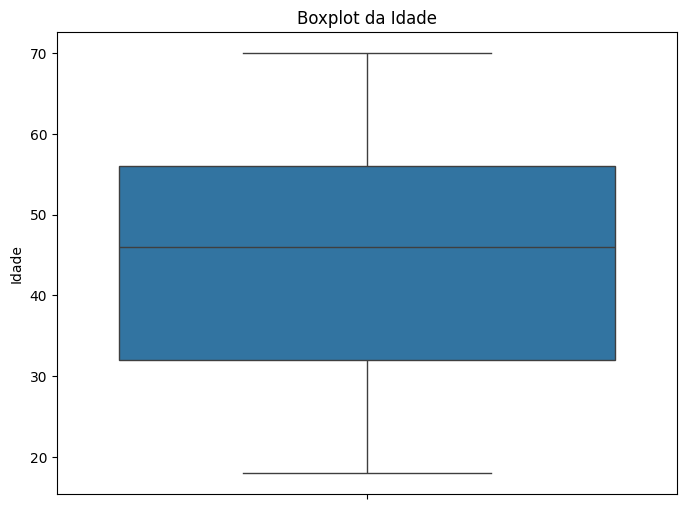

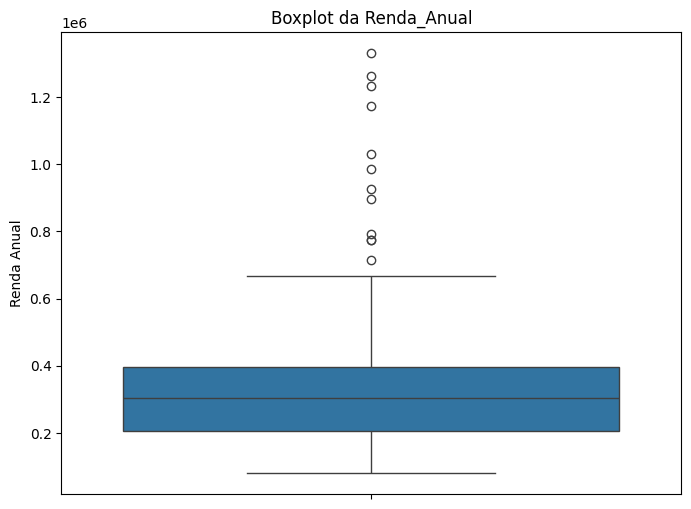

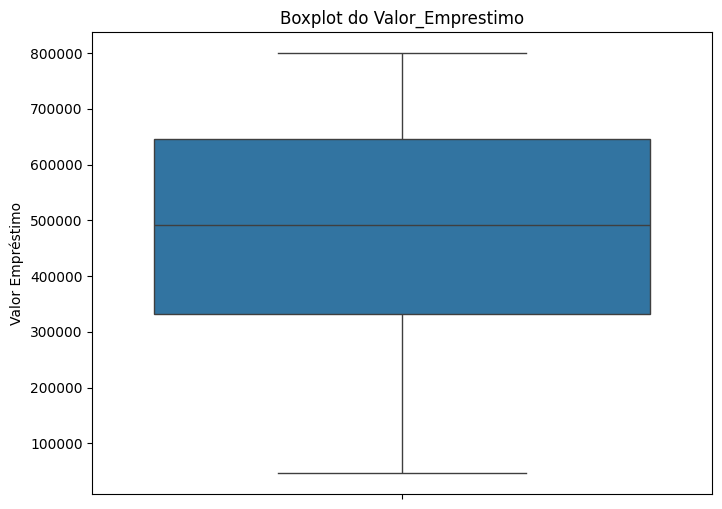

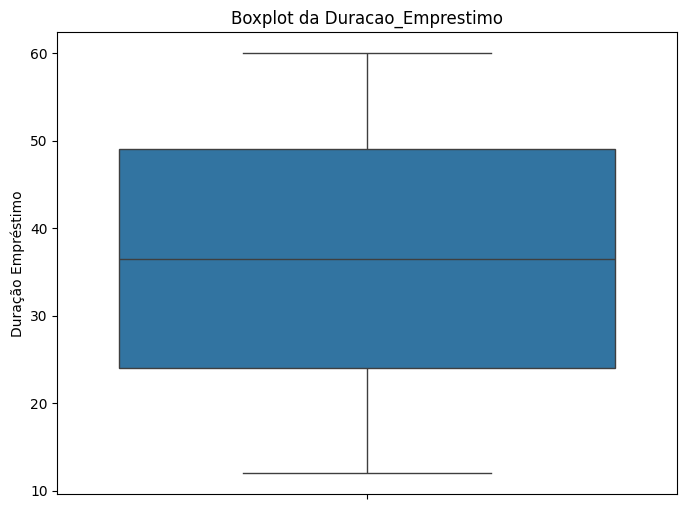

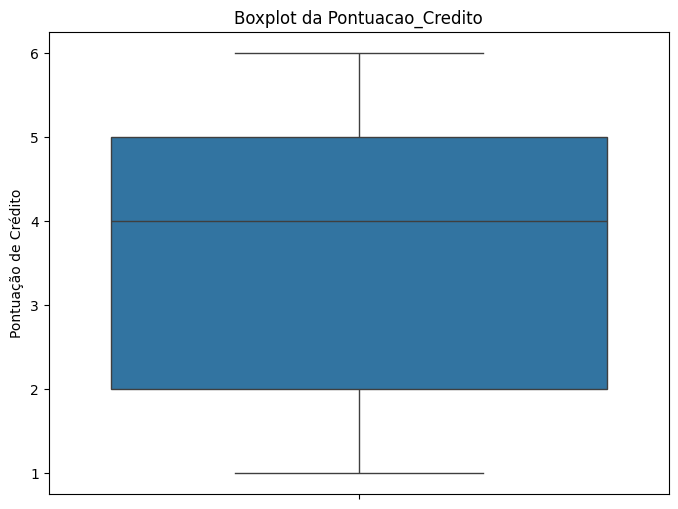

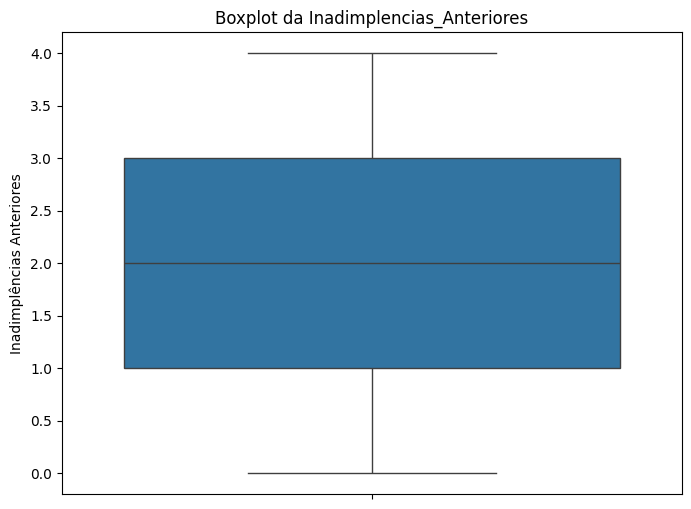

In [ ]:
# Criar boxplot para cada coluna numérica para visualizar outliers

# Boxplot para a coluna 'Idade'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Idade'])
plt.title('Boxplot da Idade')
plt.ylabel('Idade')
plt.show()

# Boxplot para a coluna 'Renda_Anual'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Renda_Anual'])
plt.title('Boxplot da Renda_Anual')
plt.ylabel('Renda Anual')
plt.show()

# Boxplot para a coluna 'Valor_Emprestimo'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Valor_Emprestimo'])
plt.title('Boxplot do Valor_Emprestimo')
plt.ylabel('Valor Empréstimo')
plt.show()

# Boxplot para a coluna 'Duracao_Emprestimo'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Duracao_Emprestimo'])
plt.title('Boxplot da Duracao_Emprestimo')
plt.ylabel('Duração Empréstimo')
plt.show()

# Boxplot para a coluna 'Pontuacao_Credito'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Pontuacao_Credito'])
plt.title('Boxplot da Pontuacao_Credito')
plt.ylabel('Pontuação de Crédito')
plt.show()

# Boxplot para a coluna 'Inadimplencias_Anteriores'
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset_copy['Inadimplencias_Anteriores'])
plt.title('Boxplot da Inadimplencias_Anteriores')
plt.ylabel('Inadimplências Anteriores')
plt.show()

### Visualização da distribuição dos dados outliers e inliers

Como o Isolation Forest Funciona

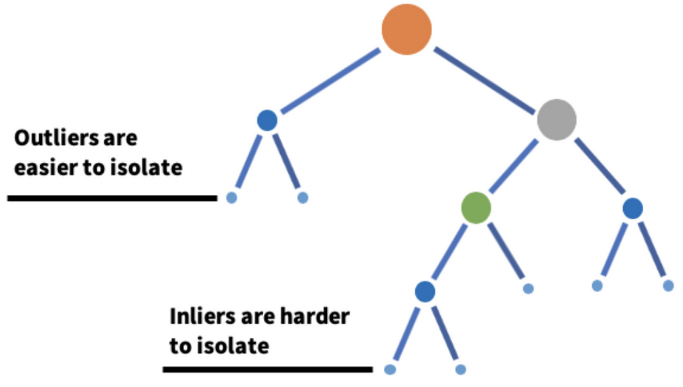

O Isolation Forest é um algoritmo de detecção de anomalias que funciona isolando observações "estranhas" ou "diferentes" dos dados normais. Em vez de modelar as características dos dados normais, o Isolation Forest identifica anomalias de maneira direta, isolando os pontos que estão "distantes" dos outros. É baseado na ideia de que pontos de anomalia devem ser mais fáceis de isolar que os pontos normais.

Construção de Árvores Aleatórias:

O algoritmo começa criando uma floresta de árvores de isolamento. Cada árvore é construída de forma aleatória, e cada divisão (ou split) da árvore separa os dados em diferentes segmentos.
A cada divisão, um recurso (feature) é escolhido aleatoriamente, e o ponto de divisão dentro desse recurso também é escolhido de forma aleatória entre o valor mínimo e máximo da amostra.
Isolamento das Observações:

O processo de divisão continua até que todas as observações estejam isoladas em nós folhas ou até que a profundidade máxima da árvore seja atingida.
Como as anomalias geralmente estão "distantes" do restante dos dados, elas tendem a ser isoladas rapidamente nas árvores. Em outras palavras, as anomalias precisam de menos divisões para serem isoladas.

Cálculo do Score de Anomalia:

Cada ponto recebe um "score de anomalia" com base no número médio de divisões (profundidade média) necessárias para isolá-lo. Quanto menos divisões forem necessárias para isolar um ponto, maior será a probabilidade de ele ser uma anomalia.
O score é calculado em uma escala de 0 a 1. Valores próximos de 1 indicam anomalias prováveis, enquanto valores próximos de 0 indicam observações normais.
Interpretação do Score:

Com base nos scores de anomalia, é possível definir um limiar. Observações com scores acima do limiar são classificadas como anomalias, enquanto as demais são consideradas normais.

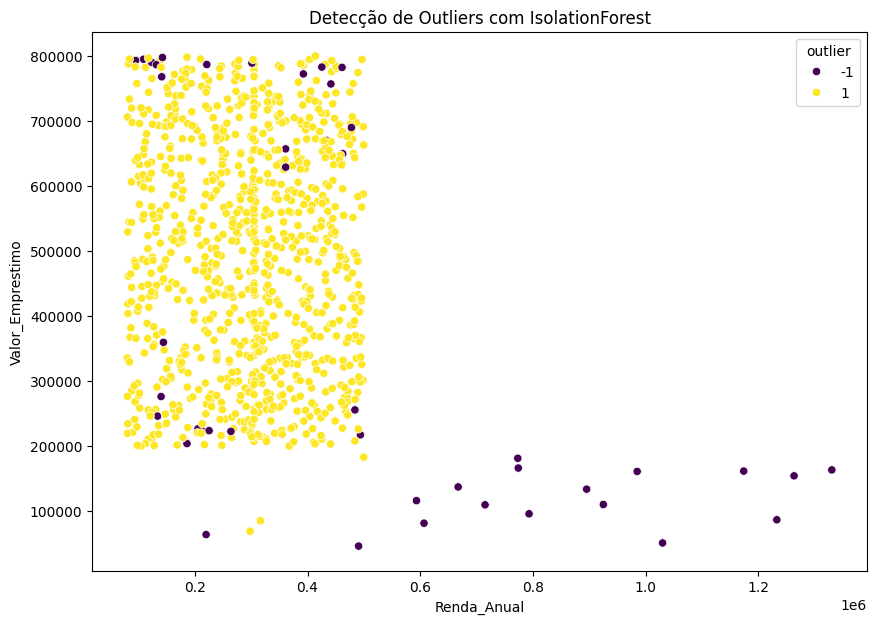

In [ ]:
# Criar modelo IsolationForest para detectar outliers
model_if = IsolationForest(random_state=42, contamination=0.0441)
model_if.fit(dataset_copy.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')) # Ajustar apenas às features numéricas

# Prever se cada ponto é um outlier (-1) ou um inlier (1)
dataset_copy['outlier'] = model_if.predict(dataset_copy.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore'))

# Criar um gráfico de dispersão com os outliers destacados
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Renda_Anual', y='Valor_Emprestimo', hue='outlier', data=dataset_copy, palette='viridis')
plt.title('Detecção de Outliers com IsolationForest')
plt.show()

In [ ]:
# Transformar o atributo Pontuação de Crédito de contínuo para discreto
dataset_copy['Pontuacao_Credito'] = pd.cut(
    dataset_copy['Pontuacao_Credito'],
    bins=[0, 1, 3, 5, 6],  # Define os intervalos
    labels=['AltoRisco', 'MédioRisco', 'BaixoRisco', 'SemRisco'],
    include_lowest=True
)

### Separação dos Outliers dos Inliers

In [ ]:
# Selecionar apenas colunas numéricas para a detecção de outliers
numeric_cols = dataset_copy.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

# Configurar e aplicar o Isolation Forest com contaminação
model_if = IsolationForest(random_state=42, contamination=0.0441)
model_if.fit(numeric_cols)

# Adicionar os rótulos de outliers ao dataset
dataset_copy['outlier'] = model_if.predict(numeric_cols)

# Filtrar apenas os outliers (rótulo -1)
outliers_df = dataset_copy[dataset_copy['outlier'] == -1]

# Exibir os dados que são outliers
print("Dados que são outliers:")
display(outliers_df.head())

# Exibir a quantidade e percentual de outliers detectados
print(f"\nQuantidade de outliers detectados: {len(outliers_df)}")
print(f"Percentual de outliers detectados: {(len(outliers_df) / len(dataset_copy) * 100):.2f}%")

Dados que são outliers:


,ID,Idade,Renda_Anual,Valor_Emprestimo,Duracao_Emprestimo,Pontuacao_Credito,Inadimplencias_Anteriores,outlier
35,36,45.0,593319.49,116262.79,30,MédioRisco,4,-1
39,40,68.0,774039.56,166407.17,28,SemRisco,4,-1
41,42,69.0,1263424.35,154400.96,59,BaixoRisco,0,-1
142,143,18.0,140113.75,276319.86,18,SemRisco,0,-1
173,174,60.0,1030112.13,51212.15,45,AltoRisco,2,-1



Quantidade de outliers detectados: 45
Percentual de outliers detectados: 4.50%


In [ ]:
# Remover os outliers
dataset_clean = dataset_copy[dataset_copy['outlier'] != -1].drop(columns=['outlier'])

# Exibir o dataset sem os outliers
print("Dados após a remoção de outliers:")
display(dataset_clean.head())

# Exibir informações gerais do dataset
print("\nInformações gerais do dataset após a remoção de outliers:")
display(dataset_clean.info())
print("\nDados ausentes por coluna após a remoção de outliers:")
display(dataset_clean.isnull().sum())

Dados após a remoção de outliers:


,ID,Idade,Renda_Anual,Valor_Emprestimo,Duracao_Emprestimo,Pontuacao_Credito,Inadimplencias_Anteriores
0,1,56.0,305368.07,548285.00,24,BaixoRisco,3
1,2,69.0,468097.54,253260.44,30,AltoRisco,1
2,3,52.0,179168.94,776999.44,60,SemRisco,1
3,4,32.0,399181.27,580976.03,17,AltoRisco,2
4,5,60.0,303131.62,652902.69,59,MédioRisco,2



Informações gerais do dataset após a remoção de outliers:
<class 'pandas.core.frame.DataFrame'>
Index: 955 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   ID                         955 non-null    int64   
 1   Idade                      955 non-null    float64 
 2   Renda_Anual                955 non-null    float64 
 3   Valor_Emprestimo           955 non-null    float64 
 4   Duracao_Emprestimo         955 non-null    int64   
 5   Pontuacao_Credito          955 non-null    category
 6   Inadimplencias_Anteriores  955 non-null    int64   
dtypes: category(1), float64(3), int64(3)
memory usage: 53.4 KB


None


Dados ausentes por coluna após a remoção de outliers:


,0
ID,0
Idade,0
Renda_Anual,0
Valor_Emprestimo,0
Duracao_Emprestimo,0
Pontuacao_Credito,0
Inadimplencias_Anteriores,0


## Etapa 7: Definição das Regras

In [ ]:
# Atualizar 'credito.csv' com os dados do dataset
dataset_clean.to_csv('credito.csv', index=False)

In [ ]:
# Definir o atributo 'ID' como meta
meta_attribute = 'ID'

# Definir o atributo 'Pontuacao_Credito' como target
target_attribute = 'Pontuacao_Credito'

# Definir os atributos restantes como features
features_attributes = [col for col in dataset_clean.columns if col not in [meta_attribute, target_attribute]]

# Exibir as regras para cada atributo
print(f"Atributo Meta: {meta_attribute}")
print(f"Atributo Target: {target_attribute}")
print(f"Atributos Features: {features_attributes}")


Atributo Meta: ID
Atributo Target: Pontuacao_Credito
Atributos Features: ['Idade', 'Renda_Anual', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencias_Anteriores']


In [ ]:
# Contar a quantidade de exemplos por classe no atributo 'Pontuacao_Credito'
print("Quantidade de exemplos por classe antes do balanceamento:")
display(dataset_clean['Pontuacao_Credito'].value_counts())

# Encontrar a classe minoritária
min_class = dataset_clean['Pontuacao_Credito'].value_counts().idxmin()

# Encontrar a quantidade de exemplos da classe minoritária
min_class_count = dataset_clean['Pontuacao_Credito'].value_counts().min()

# Criar um DataFrame vazio para armazenar o conjunto de dados balanceado
dataset_balanced = pd.DataFrame(columns=dataset_clean.columns)

# Balancear os dados para cada classe
for class_label in dataset_clean['Pontuacao_Credito'].unique():
    df_class = dataset_clean[dataset_clean['Pontuacao_Credito'] == class_label]
    if len(df_class) > min_class_count:
        df_class_balanced = resample(df_class,
                                       replace=False,
# Amostrar sem substituição
n_samples=min_class_count,

# Reduzir para o número da classe minoritária
 random_state=42)

# Para reprodutibilidade
    else:
        df_class_balanced = df_class
    dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])

# Redefinir o índice do conjunto de dados balanceado
dataset_balanced = dataset_balanced.reset_index(drop=True)

# Exibir a quantidade de exemplos por classe no conjunto de dados balanceado
print("\nQuantidade de exemplos por classe após o balanceamento:")
display(dataset_balanced['Pontuacao_Credito'].value_counts())

Quantidade de exemplos por classe antes do balanceamento:


,count
Pontuacao_Credito,
MédioRisco,313
BaixoRisco,303
SemRisco,205
AltoRisco,134



Quantidade de exemplos por classe após o balanceamento:


/tmp/ipython-input-3193779767.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])
/tmp/ipython-input-3193779767.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])


,count
Pontuacao_Credito,
AltoRisco,134
MédioRisco,134
BaixoRisco,134
SemRisco,134


In [ ]:
# Separar as colunas target e meta das demais features
meta_data = dataset_balanced['ID']
target_data = dataset_balanced['Pontuacao_Credito']
features_data = dataset_balanced.drop(columns=['ID', 'Pontuacao_Credito'])

# Criar um objeto MinMaxScaler
scaler = MinMaxScaler()

# Normalizar as features
features_scaled = scaler.fit_transform(features_data)

# Converter o array numpy em DataFrame
features_scaled_df = pd.DataFrame(features_scaled, columns=features_data.columns)

# Criar um novo dataset com a ordem target, meta e demais atributos
dataset_normalized = pd.concat([meta_data, target_data, features_scaled_df], axis=1)

print("Dados após a normalização (primeiras 5 linhas):")
display(dataset_normalized.head())

Dados após a normalização (primeiras 5 linhas):


,ID,Pontuacao_Credito,Idade,Renda_Anual,Valor_Emprestimo,Duracao_Emprestimo,Inadimplencias_Anteriores
0,566,BaixoRisco,0.596154,0.771007,0.253773,0.000000,0.00
1,736,BaixoRisco,0.942308,0.793143,0.542970,0.854167,0.00
2,353,BaixoRisco,0.903846,0.269295,0.931797,0.604167,0.00
3,794,BaixoRisco,0.134615,0.230455,0.544839,0.187500,0.50
4,189,BaixoRisco,0.519231,0.235237,0.562064,0.208333,0.25


In [ ]:
# Carregar o dataset
X = dataset_normalized.drop(columns=['ID', 'Pontuacao_Credito'])
y = dataset_normalized['Pontuacao_Credito']

# Separar os dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Salvar os datasets em novos arquivos CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Exibir informações
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (428, 5)
Shape de X_test: (108, 5)
Shape de y_train: (428,)
Shape de y_test: (108,)


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

# Exibir o número de linhas e colunas
print("Shape de X_train:", X_train.shape)
print("Shape de y_train:", y_train.shape)

# Carregar o dataset de teste
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# Exibir o número de linhas e colunas
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (428, 5)
Shape de y_train: (428, 1)
Shape de X_test: (108, 5)
Shape de y_test: (108, 1)


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze() # .squeeze() para converter DataFrame de coluna única em Series

# Criar o modelo SVM
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=200,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=42 # Adicionado random_state para reprodutibilidade
)

# Definir o número de folds para cross-validation
n_splits = 5

# Criar o objeto StratifiedKFold para garantir que a distribuição das classes seja mantida em cada fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Realizar a cross-validation
accuracy_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='accuracy')
precision_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='precision_weighted')
recall_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='recall_weighted')
f1_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='f1_weighted')

# Exibir as métricas de classificação
print("Métricas de Classificação do SVM (Cross-Validation):")
print(f"Acurácia Média: {accuracy_scores_svm.mean():.4f}")
print(f"Precisão Média: {precision_scores_svm.mean():.4f}")
print(f"Recall Médio: {recall_scores_svm.mean():.4f}")
print(f"F1-Score Médio: {f1_scores_svm.mean():.4f}")

Métricas de Classificação do SVM (Cross-Validation):
Acurácia Média: 0.2874
Precisão Média: 0.2882
Recall Médio: 0.2874
F1-Score Médio: 0.2821


In [ ]:
# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Salvar o modelo treinado em um arquivo
with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

print("Modelo SVM treinado e salvo como 'svm_model.pkl'")

Modelo SVM treinado e salvo como 'svm_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=200).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

# Criar o modelo MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=42, # Adicionado random_state para reprodutibilidade
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000
)

# Definir o número de folds para cross-validation
n_splits = 5

# Criar o objeto StratifiedKFold para garantir que a distribuição das classes seja mantida em cada fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Realizar a cross-validation
accuracy_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='accuracy')
precision_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='precision_weighted')
recall_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='recall_weighted')
f1_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='f1_weighted')

# Exibir as métricas de classificação
print("Métricas de Classificação do MLP (Cross-Validation):")
print(f"Acurácia Média: {accuracy_scores_mlp.mean():.4f}")
print(f"Precisão Média: {precision_scores_mlp.mean():.4f}")
print(f"Recall Médio: {recall_scores_mlp.mean():.4f}")
print(f"F1-Score Médio: {f1_scores_mlp.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Métricas de Classificação do MLP (Cross-Validation):
Acurácia Média: 0.2946
Precisão Média: 0.2937
Recall Médio: 0.2946
F1-Score Médio: 0.2880


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Treinar o modelo MLP
mlp_model.fit(X_train, y_train)

# Salvar o modelo treinado em um arquivo
with open('mlp_model.pkl', 'wb') as file:
    pickle.dump(mlp_model, file)

print("Modelo MLP treinado e salvo como 'mlp_model.pkl'")

Modelo MLP treinado e salvo como 'mlp_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Carregar o modelo treinado
with open('svm_model.pkl', 'rb') as file:
    loaded_svm_model = pickle.load(file)

# Carregar o dataset de teste
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Separar as features e o target do dataset de teste
X_test_features = X_test
y_test_true = y_test

# Fazer as previsões usando o modelo carregado
y_pred_svm = loaded_svm_model.predict(X_test_features)

# Calcular as métricas de avaliação
accuracy_svm = accuracy_score(y_test_true, y_pred_svm)
precision_svm = precision_score(y_test_true, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test_true, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test_true, y_pred_svm, average='weighted')

# Exibir as métricas de avaliação
print("Métricas de Avaliação do SVM no conjunto de teste:")
print(f"Acurácia: {accuracy_svm:.4f}")
print(f"Precisão: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

Métricas de Avaliação do SVM no conjunto de teste:
Acurácia: 0.3148
Precisão: 0.3328
Recall: 0.3148
F1-Score: 0.3157


In [ ]:
# Carregar o modelo treinado (SVM)
with open('svm_model.pkl', 'rb') as file:
    loaded_svm_model = pickle.load(file)

# Carregar o scaler treinado
with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

# Criar um dicionário com os valores de entrada
# Os valores devem estar na mesma ordem e formato que as features de treino
# 'Idade', 'Renda_Anual', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencias_Anteriores'
input_data = {
    'Idade': [50],
    'Renda_Anual': [150000],
    'Valor_Emprestimo': [300000],
    'Duracao_Emprestimo': [36],
    'Inadimplencias_Anteriores': [1]
}

# Converter o dicionário em um DataFrame
input_df = pd.DataFrame(input_data)

# Normalizar os dados de entrada usando o scaler carregado
input_scaled = loaded_scaler.transform(input_df)
input_scaled_df = pd.DataFrame(input_scaled, columns=input_df.columns)

# Fazer a previsão usando o modelo carregado
prediction = loaded_svm_model.predict(input_scaled_df)

# Exibir a previsão
print(f"A previsão de Pontuação de Crédito para os dados de entrada é: {prediction[0]}")

A previsão de Pontuação de Crédito para os dados de entrada é: BaixoRisco


## Etapa 8: Balanceamento dos Dados

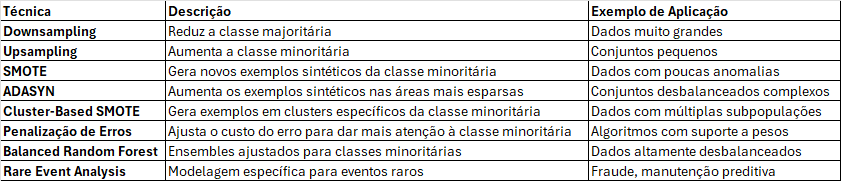

In [ ]:
# Contar a quantidade de exemplos por classe no atributo 'Pontuacao_Credito'
print("Quantidade de exemplos por classe antes do balanceamento:")
display(dataset_clean['Pontuacao_Credito'].value_counts())

# Encontrar a classe minoritária
min_class = dataset_clean['Pontuacao_Credito'].value_counts().idxmin()

# Encontrar a quantidade de exemplos da classe minoritária
min_class_count = dataset_clean['Pontuacao_Credito'].value_counts().min()

# Criar um DataFrame vazio para armazenar o conjunto de dados balanceado
dataset_balanced = pd.DataFrame(columns=dataset_clean.columns)

# Balancear os dados para cada classe
for class_label in dataset_clean['Pontuacao_Credito'].unique():
    df_class = dataset_clean[dataset_clean['Pontuacao_Credito'] == class_label]
    if len(df_class) > min_class_count:
        df_class_balanced = resample(df_class,
                                       replace=False,    # Amostrar sem substituição
                                       n_samples=min_class_count, # Reduzir para o número da classe minoritária
                                       random_state=42) # Para reprodutibilidade
    else:
        df_class_balanced = df_class
    dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])

# Redefinir o índice do conjunto de dados balanceado
dataset_balanced = dataset_balanced.reset_index(drop=True)

# Exibir a quantidade de exemplos por classe no conjunto de dados balanceado
print("\nQuantidade de exemplos por classe após o balanceamento:")
display(dataset_balanced['Pontuacao_Credito'].value_counts())

Quantidade de exemplos por classe antes do balanceamento:


,count
Pontuacao_Credito,
MédioRisco,313
BaixoRisco,303
SemRisco,205
AltoRisco,134



Quantidade de exemplos por classe após o balanceamento:


/tmp/ipython-input-2756443440.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])
/tmp/ipython-input-2756443440.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset_balanced = pd.concat([dataset_balanced, df_class_balanced])


,count
Pontuacao_Credito,
AltoRisco,134
MédioRisco,134
BaixoRisco,134
SemRisco,134


## Etapa 9: Normalização dos Dados

In [ ]:
# Separar as colunas target e meta das demais features
meta_data = dataset_balanced['ID']
target_data = dataset_balanced['Pontuacao_Credito']
features_data = dataset_balanced.drop(columns=['ID', 'Pontuacao_Credito'])

# Criar um objeto MinMaxScaler
scaler = MinMaxScaler()

# Normalizar as features
features_scaled = scaler.fit_transform(features_data)

# Converter o array numpy em DataFrame
features_scaled_df = pd.DataFrame(features_scaled, columns=features_data.columns)

# Criar um novo dataset com a ordem target, meta e demais atributos
dataset_normalized = pd.concat([meta_data, target_data, features_scaled_df], axis=1)

# Salvar o scaler treinado em um arquivo
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Dados após a normalização (primeiras 5 linhas):")
display(dataset_normalized.head())

Dados após a normalização (primeiras 5 linhas):


,ID,Pontuacao_Credito,Idade,Renda_Anual,Valor_Emprestimo,Duracao_Emprestimo,Inadimplencias_Anteriores
0,566,BaixoRisco,0.596154,0.771007,0.253773,0.000000,0.00
1,736,BaixoRisco,0.942308,0.793143,0.542970,0.854167,0.00
2,353,BaixoRisco,0.903846,0.269295,0.931797,0.604167,0.00
3,794,BaixoRisco,0.134615,0.230455,0.544839,0.187500,0.50
4,189,BaixoRisco,0.519231,0.235237,0.562064,0.208333,0.25


In [ ]:
# Carregar o modelo treinado (MLP)
with open('mlp_model.pkl', 'rb') as file:
    loaded_mlp_model = pickle.load(file)

# Carregar o dataset de teste
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Separar as features e o target do dataset de teste
X_test_features = X_test
y_test_true = y_test

# Fazer as previsões usando o modelo carregado
y_pred_mlp = loaded_mlp_model.predict(X_test_features)

# Calcular as métricas de avaliação
accuracy_mlp = accuracy_score(y_test_true, y_pred_mlp)
precision_mlp = precision_score(y_test_true, y_pred_mlp, average='weighted')
recall_mlp = recall_score(y_test_true, y_pred_mlp, average='weighted')
f1_mlp = f1_score(y_test_true, y_pred_mlp, average='weighted')

# Exibir as métricas de avaliação
print("Métricas de Avaliação do MLP no conjunto de teste:")
print(f"Acurácia: {accuracy_mlp:.4f}")
print(f"Precisão: {precision_mlp:.4f}")
print(f"Recall: {recall_mlp:.4f}")
print(f"F1-Score: {f1_mlp:.4f}")

Métricas de Avaliação do MLP no conjunto de teste:
Acurácia: 0.3426
Precisão: 0.3979
Recall: 0.3426
F1-Score: 0.3436


In [ ]:
print(f"F1-Score do SVM no conjunto de teste: {f1_svm:.4f}")
print(f"F1-Score do MLP no conjunto de teste: {f1_mlp:.4f}")

if f1_svm > f1_mlp:
    print("O modelo SVM teve um desempenho melhor no conjunto de teste com base no F1-Score.")
elif f1_mlp > f1_svm:
    print("O modelo MLP teve um desempenho melhor no conjunto de teste com base no F1-Score.")
else:
    print("Ambos os modelos tiveram o mesmo desempenho no conjunto de teste com base no F1-Score.")

F1-Score do SVM no conjunto de teste: 0.3157
F1-Score do MLP no conjunto de teste: 0.3436
O modelo MLP teve um desempenho melhor no conjunto de teste com base no F1-Score.


## Etapa 10: Separação dos Dados para Treinamento/Teste e Validação

In [ ]:
# Carregar o dataset
X = dataset_normalized.drop(columns=['ID', 'Pontuacao_Credito'])
y = dataset_normalized['Pontuacao_Credito']

# Separar os dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Salvar os datasets em novos arquivos CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Exibir informações
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (428, 5)
Shape de X_test: (108, 5)
Shape de y_train: (428,)
Shape de y_test: (108,)


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

# Exibir o número de linhas e colunas
print("Shape de X_train:", X_train.shape)
print("Shape de y_train:", y_train.shape)

# Carregar o dataset de teste
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# Exibir o número de linhas e colunas
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (428, 5)
Shape de y_train: (428, 1)
Shape de X_test: (108, 5)
Shape de y_test: (108, 1)


## Etapa 11: Treinamento dos Modelos

### Support Vector Machine (SVM)


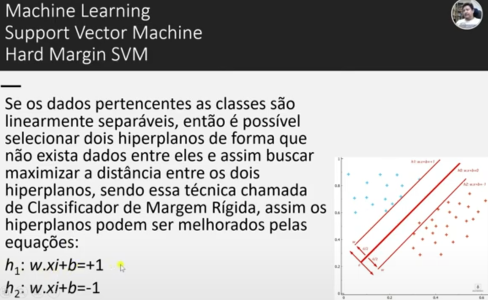

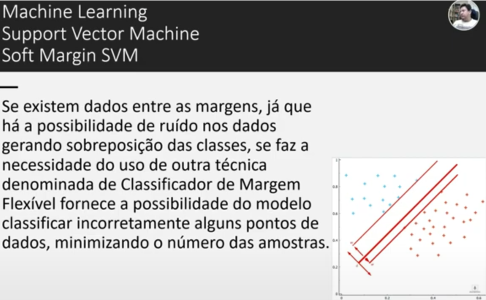

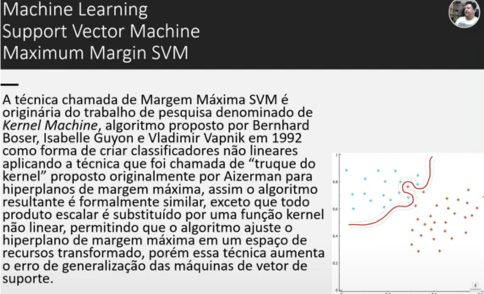

[Explicação do SVM](https://youtu.be/UrR5tcY-wYw)

In [ ]:
# Criar modelo SVM com hiperparâmetros específicos
svm_model = SVC(
    C=1.0,  # Parâmetro de regularização (custo da classificação incorreta)
    kernel='rbf',  # Kernel para o modelo (radial basis function)
    degree=3,  # Grau do polinômio para o kernel (relevante para kernel='poly')
    gamma='scale',  # Coeficiente do kernel (relevante para kernel='rbf', 'poly', 'sigmoid')
    coef0=0.0,  # Termo independente para o kernel (relevante para kernel='poly', 'sigmoid')
    shrinking=True,  # Utilização do shrinking heuristic para otimizar a solução
    probability=False,  # Calcular probabilidades de classe
    tol=0.001,  # Tolerância para a otimização
    cache_size=200,  # Tamanho do cache em MB
    class_weight=None,  # Pesos para as classes (pode ser usado para lidar com classes desbalanceadas)
    verbose=False,  # Mostrar mensagens durante a execução
    max_iter=200,  # Número máximo de iterações para a otimização (-1 significa ilimitado)
    decision_function_shape='ovr',  # Formato da função de decisão ('ovo' para one-vs-one, 'ovr' para one-vs-rest)
    break_ties=False,  # Quebrar empates com maior precisão (relevante para classificação multiclasse)
    random_state=None  # Semente aleatória para reprodutibilidade
)

# Exibir os hiperparâmetros
print("Hiperparâmetros do modelo SVM:")
print(svm_model.get_params())

Hiperparâmetros do modelo SVM:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': 200, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze() # .squeeze() para converter DataFrame de coluna única em Series

# Criar o modelo SVM
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=200,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=42 # Adicionado random_state para reprodutibilidade
)

# Definir o número de folds para cross-validation
n_splits = 5

# Criar o objeto StratifiedKFold para garantir que a distribuição das classes seja mantida em cada fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Realizar a cross-validation
accuracy_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='accuracy')
precision_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='precision_weighted')
recall_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='recall_weighted')
f1_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=skf, scoring='f1_weighted')

# Exibir as métricas de classificação
print("Métricas de Classificação do SVM (Cross-Validation):")
print(f"Acurácia Média: {accuracy_scores_svm.mean():.4f}")
print(f"Precisão Média: {precision_scores_svm.mean():.4f}")
print(f"Recall Médio: {recall_scores_svm.mean():.4f}")
print(f"F1-Score Médio: {f1_scores_svm.mean():.4f}")

Métricas de Classificação do SVM (Cross-Validation):
Acurácia Média: 0.2874
Precisão Média: 0.2882
Recall Médio: 0.2874
F1-Score Médio: 0.2821


In [ ]:
# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Salvar o modelo treinado em um arquivo
with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

print("Modelo SVM treinado e salvo como 'svm_model.pkl'")

Modelo SVM treinado e salvo como 'svm_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=200).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
# Carregar o modelo treinado (SVM)
with open('svm_model.pkl', 'rb') as file:
    loaded_svm_model = pickle.load(file)

# Carregar o dataset de teste
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Separar as features e o target do dataset de teste
X_test_features = X_test
y_test_true = y_test

# Fazer as previsões usando o modelo carregado
y_pred_svm = loaded_svm_model.predict(X_test_features)

# Calcular as métricas de avaliação
accuracy_svm = accuracy_score(y_test_true, y_pred_svm)
precision_svm = precision_score(y_test_true, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test_true, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test_true, y_pred_svm, average='weighted')

# Exibir as métricas de avaliação
print("Métricas de Avaliação do SVM no conjunto de teste:")
print(f"Acurácia: {accuracy_svm:.4f}")
print(f"Precisão: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

Métricas de Avaliação do SVM no conjunto de teste:
Acurácia: 0.3148
Precisão: 0.3328
Recall: 0.3148
F1-Score: 0.3157


### Multilayer Perceptron (MLP)

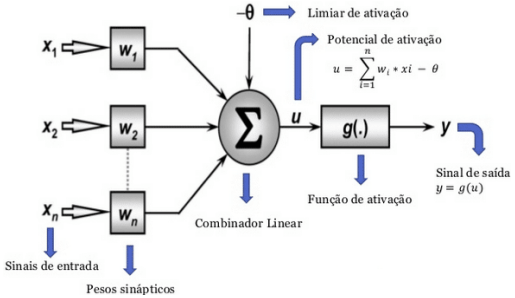

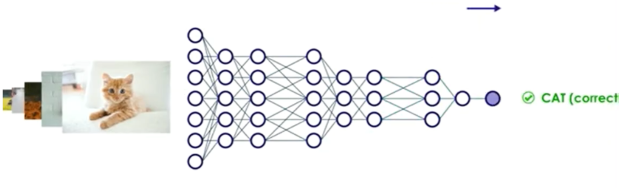

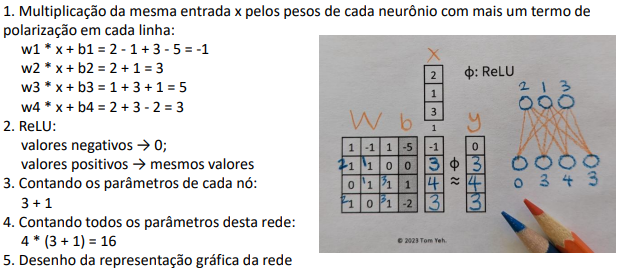

[Explicação do MLP](https://youtu.be/oivb9285i54)

In [ ]:
# Criar um modelo MLP com hiperparâmetros específicos
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),  # Número de neurônios em cada camada oculta
    activation='relu',  # Função de ativação
    solver='adam',  # Algoritmo de otimização
    alpha=0.0001,  # Termo de regularização L2
    batch_size='auto',  # Tamanho do batch para o treinamento
    learning_rate='constant',  # Taxa de aprendizado
    learning_rate_init=0.001,  # Taxa de aprendizado inicial
    power_t=0.5,  # Parâmetro para o algoritmo de otimização 'sgd'
    max_iter=200,  # Número máximo de iterações
    shuffle=True,  # Embaralhar os dados a cada época
    random_state=None,  # Semente aleatória
    tol=0.0001,  # Tolerância para o critério de parada
    verbose=False,  # Mostrar mensagens durante o treinamento
    warm_start=False,  # Reutilizar a solução da inicialização anterior
    momentum=0.9,  # Parâmetro para o algoritmo de otimização 'sgd'
    nesterovs_momentum=True,  # Utilizar o momentum de Nesterov
    early_stopping=False,  # Parar o treinamento precocemente
    validation_fraction=0.1,  # Fração de dados para validação
    beta_1=0.9,  # Parâmetro para o algoritmo de otimização 'adam'
    beta_2=0.999,  # Parâmetro para o algoritmo de otimização 'adam'
    epsilon=1e-08,  # Parâmetro para o algoritmo de otimização 'adam'
    n_iter_no_change=10,  # Número máximo de épocas sem melhoria
    max_fun=15000  # Número máximo de chamadas para a função de custo
)

# Exibir os hiperparâmetros
print("Hiperparâmetros do modelo MLP: ")
print(mlp_model.get_params())

Hiperparâmetros do modelo MLP: 
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': None, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


In [ ]:
# Carregar o dataset de treino
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

# Criar o modelo MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=42, # Adicionado random_state para reprodutibilidade
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000
)

# Definir o número de folds para cross-validation
n_splits = 5

# Criar o objeto StratifiedKFold para garantir que a distribuição das classes seja mantida em cada fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Realizar a cross-validation
accuracy_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='accuracy')
precision_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='precision_weighted')
recall_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='recall_weighted')
f1_scores_mlp = cross_val_score(mlp_model, X_train, y_train, cv=skf, scoring='f1_weighted')

# Exibir as métricas de classificação
print("Métricas de Classificação do MLP (Cross-Validation):")
print(f"Acurácia Média: {accuracy_scores_mlp.mean():.4f}")
print(f"Precisão Média: {precision_scores_mlp.mean():.4f}")
print(f"Recall Médio: {recall_scores_mlp.mean():.4f}")
print(f"F1-Score Médio: {f1_scores_mlp.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Métricas de Classificação do MLP (Cross-Validation):
Acurácia Média: 0.2946
Precisão Média: 0.2937
Recall Médio: 0.2946
F1-Score Médio: 0.2880


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Treinar o modelo MLP
mlp_model.fit(X_train, y_train)

# Salvar o modelo treinado em um arquivo
with open('mlp_model.pkl', 'wb') as file:
    pickle.dump(mlp_model, file)

print("Modelo MLP treinado e salvo como 'mlp_model.pkl'")

Modelo MLP treinado e salvo como 'mlp_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Carregar o modelo treinado (MLP)
with open('mlp_model.pkl', 'rb') as file:
    loaded_mlp_model = pickle.load(file)

# Carregar o scaler treinado
with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

# Criar um dicionário com os valores de entrada
# Os valores devem estar na mesma ordem e formato que as features de treino
# 'Idade', 'Renda_Anual', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencias_Anteriores'
input_data = {
    'Idade': [50],
    'Renda_Anual': [150000],
    'Valor_Emprestimo': [300000],
    'Duracao_Emprestimo': [36],
    'Inadimplencias_Anteriores': [1]
}

# Converter o dicionário em um DataFrame
input_df = pd.DataFrame(input_data)

# Normalizar os dados de entrada usando o scaler carregado
input_scaled = loaded_scaler.transform(input_df)
input_scaled_df = pd.DataFrame(input_scaled, columns=input_df.columns)

# Fazer a previsão usando o modelo carregado
prediction = loaded_mlp_model.predict(input_scaled_df)

# Exibir a previsão
print(f"A previsão de Pontuação de Crédito para os dados de entrada é: {prediction[0]}")

A previsão de Pontuação de Crédito para os dados de entrada é: SemRisco


## Etapa 12: Competição de modelos

## Etapa 12: Produção

In [ ]:
# Carregar o modelo treinado (SVM)
with open('svm_model.pkl', 'rb') as file:
    loaded_svm_model = pickle.load(file)

# Carregar o scaler treinado
with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

# Criar um dicionário com os valores de entrada
# Os valores devem estar na mesma ordem e formato que as features de treino
# 'Idade', 'Renda_Anual', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencias_Anteriores'
input_data = {
    'Idade': [50],
    'Renda_Anual': [150000],
    'Valor_Emprestimo': [300000],
    'Duracao_Emprestimo': [36],
    'Inadimplencias_Anteriores': [1]
}

# Converter o dicionário em um DataFrame
input_df = pd.DataFrame(input_data)

# Normalizar os dados de entrada usando o scaler carregado
input_scaled = loaded_scaler.transform(input_df)
input_scaled_df = pd.DataFrame(input_scaled, columns=input_df.columns)

# Fazer a previsão usando o modelo carregado
prediction = loaded_svm_model.predict(input_scaled_df)

# Exibir a previsão
print(f"A previsão de Pontuação de Crédito para os dados de entrada é: {prediction[0]}")

A previsão de Pontuação de Crédito para os dados de entrada é: BaixoRisco
